# Forecasting — National Crime Risk Index (Ecuador)

**Objective:** Forecast the monthly national crime risk index for 2024–2025, training on 2019–2023.

**Methodological questions answered by this notebook:**
1. Which monthly national target definition is most stable and predictable?
2. Which models show the best predictive performance on the test period?
3. Does the conclusion hold when contrasting monthly vs. weekly frequency?

**Final models compared:**

| Model | Type | Library |
|---|---|---|
| ETS | Seasonal exponential smoothing (Holt-Winters) | statsmodels |
| XGBoost | Gradient boosting with lag features | xgboost |
| LSTM | Recurrent neural network with long-term memory | Keras/TensorFlow |
| ARIMA | Classic linear model | statsmodels / pmdarima |
| Prophet | Additive trend + seasonality | prophet |

**Fixed temporal split:** train 2019-01 to 2023-12, test 2024-01 to 2025-12.

**Main metrics:** RMSE and MAE.

**Reproducibility note:**
- The test period is never used to estimate PCA weights, normalization parameters, or early stopping.
- This notebook exports final tables ready to include in the article.

## Quick Reading Guide (no forecasting background required)

This notebook is organized in three layers:

1. **Building the target series**: defines what "national risk" means and how it is computed.
2. **Modeling and validation**: models are tested with strict temporal separation (train/test).
3. **Comparison and decision**: the winner is chosen by test performance, not by complexity.

### Key Concepts

- **Time series**: sequence of values ordered by date.
- **Temporal train/test**: trained on past years, evaluated on future years.
- **Baseline**: simple reference model; if a more complex model can't beat it, it's not worth defending.

Practical rule: a model "wins" if it consistently reduces RMSE and MAE versus the naïve baseline.

In [24]:
import os
import warnings
import unicodedata
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import matplotlib
import seaborn as sns

from functools import reduce
from sklearn.preprocessing import StandardScaler, MinMaxScaler
from sklearn.decomposition import PCA
from sklearn.metrics import mean_squared_error, mean_absolute_error

warnings.filterwarnings('ignore')
matplotlib.rcParams['figure.dpi'] = 120
plt.rcParams.update({
    'axes.titlesize'  : 14,
    'axes.labelsize'  : 13,
    'xtick.labelsize' : 11,
    'ytick.labelsize' : 11,
    'legend.fontsize' : 11,
    'figure.titlesize': 15,
})
os.makedirs('plots', exist_ok=True)

SEED = 42
np.random.seed(SEED)


## Step 1 — Data Loading and Monthly National Index Reconstruction

The full EDA pipeline is replicated here (cleaning, normalization, PCA → weights, index construction) to produce the **monthly national** index ready for forecasting.

### What Exactly Is Being Built in Step 1?

There is no prediction yet at this stage — this is where we define the variable we will later try to forecast.

Conceptual flow:

1. Events from different sources are unified (homicides, weapons, arrests).
2. Scale differences are corrected using population rates.
3. PCA weights are derived to combine indicators without manual arbitrariness.
4. A single monthly national index is obtained.

This matters because the final model will only be as good as the quality and coherence of this target series.

In [25]:
# ── Data Loading ─────────────────────────────────────────────────────────
files = {
    'homicidios'     : 'data/homicidios 2014-2026.xlsx',
    'armas'          : 'data/armas ilicitas 2017-2026.xlsx',
    'arrestos'       : 'data/detenidos 2019 - 2026.xlsx',
    'poblacion_anual': 'data/poblacion_cantones_2019-2025.csv',
}

dfs = {}
for name, path in files.items():
    ext = os.path.splitext(path)[-1]
    if ext == '.xlsx' and name != 'homicidios':
        dfs[name] = pd.read_excel(path, sheet_name=1)
    elif ext == '.csv':
        dfs[name] = pd.read_csv(path, sep=';' if name == 'poblacion_anual' else ',')
    else:
        dfs[name] = pd.read_excel(path)

print('Sources loaded:')
for name, df in dfs.items():
    print(f'  {name:<18}: {df.shape}')

Sources loaded:
  homicidios        : (41221, 33)
  armas             : (72555, 28)
  arrestos          : (571910, 35)
  poblacion_anual   : (221, 9)


In [26]:
# ── Cleaning and normalization (replicated from EDA) ─────────────────────
def clean_canton(s):
    s = str(s).strip().upper()
    s = unicodedata.normalize('NFKD', s)
    s = s.encode('ascii', 'ignore').decode()
    return ' '.join(s.split())

CANTON_NORM = {'DISTRITO METROPOLITANO DE QUITO': 'QUITO'}
PROV_NORM   = {'SANTO DOMINGO DE LOS TSACHILAS': 'STO DGO DE LOS TSACHILAS'}

for src, col_fecha in [
    ('homicidios', 'fecha_infraccion'),
    ('armas',      'fecha_evento'),
    ('arrestos',   'fecha_detencion_aprehension'),
]:
    dt = pd.to_datetime(dfs[src][col_fecha], errors='coerce')
    dfs[src]['anio'] = dt.dt.year
    dfs[src]['mes']  = dt.dt.month
    # First day of month as monthly label
    dfs[src]['fecha_mes'] = dt.dt.to_period('M').dt.to_timestamp()

dfs['homicidios']['canton_key']    = dfs['homicidios']['canton'].apply(clean_canton)
dfs['homicidios']['provincia_key'] = dfs['homicidios']['provincia'].apply(clean_canton)
dfs['armas']['canton_key']         = dfs['armas']['nombre_canton'].apply(clean_canton)
dfs['armas']['provincia_key']      = dfs['armas']['nombre_provincia'].apply(clean_canton)
dfs['arrestos']['canton_key']      = dfs['arrestos']['nombre_canton'].apply(clean_canton)
dfs['arrestos']['provincia_key']   = dfs['arrestos']['nombre_provincia'].apply(clean_canton)

# ── Master monthly dataset ───────────────────────────────────────────────
KEY = ['canton_key', 'provincia_key', 'fecha_mes']

hom = (dfs['homicidios'].dropna(subset=['canton_key', 'anio', 'fecha_mes'])
       .groupby(KEY).size().reset_index(name='homicidios'))
armas_agg = (dfs['armas'].dropna(subset=['canton_key', 'anio', 'fecha_mes'])
             .groupby(KEY).size().reset_index(name='armas_incautadas'))
arr = (dfs['arrestos'].dropna(subset=['canton_key', 'anio', 'fecha_mes'])
       .groupby(KEY).size().reset_index(name='arrestos'))

master = reduce(lambda l, r: l.merge(r, on=KEY, how='outer'), [hom, armas_agg, arr])
# Extract year from month for population join (annual)
master['anio'] = master['fecha_mes'].dt.year.astype('Int64')

pop_long = dfs['poblacion_anual'].melt(
    id_vars=['Provincia', 'Cantón'],
    value_vars=[str(y) for y in range(2019, 2026)],
    var_name='anio', value_name='poblacion')
pop_long['anio']         = pop_long['anio'].astype(int)
pop_long['canton_key']   = pop_long['Cantón'].apply(clean_canton).replace(CANTON_NORM)
pop_long['provincia_key']= pop_long['Provincia'].apply(clean_canton).replace(PROV_NORM)

master = master.merge(
    pop_long[['canton_key', 'provincia_key', 'anio', 'poblacion']],
    on=['canton_key', 'provincia_key', 'anio'], how='left')

print(f'Monthly dataset: {master.shape}  |  cantons: {master.canton_key.nunique()}')

Monthly dataset: (21363, 8)  |  cantons: 221


In [27]:
# ── Index constants + PCA fitted on train (2019-2023) ────────────────────
INDICADORES  = ['homicidios', 'armas_incautadas', 'arrestos']
RATES_LABELS = ['Homicides/1k', 'Weapons/1k', 'Arrests/1k']
RATES  = [f'{c}_r1k'   for c in INDICADORES]
Z_COLS = [f'{c}_r1k_z' for c in INDICADORES]

# Index parameters fitted ONLY on train; no leakage to test/2024-2025
ANIOS_PCA_TRAIN = list(range(2019, 2024))

master_annual = (
    master[master['anio'].isin(ANIOS_PCA_TRAIN)]
    .groupby(['canton_key', 'provincia_key', 'anio'], as_index=False)
    .agg(
        homicidios       =('homicidios',       'sum'),
        armas_incautadas =('armas_incautadas', 'sum'),
        arrestos         =('arrestos',         'sum'),
        poblacion        =('poblacion',        'first'),
    )
).reset_index(drop=True)

master_annual[INDICADORES] = master_annual[INDICADORES].fillna(0)
for col in INDICADORES:
    master_annual[f'{col}_r1k'] = master_annual[col] / master_annual['poblacion'] * 1000

# ── Bayesian shrinkage (identical to EDA) ────────────────────────────────
# r̂_i = w_i · r_i + (1 − w_i) · r̄,  w_i = pop_i / (pop_i + m)
m_shrink = master_annual['poblacion'].median()
for col in INDICADORES:
    rate_col    = f'{col}_r1k'
    global_rate = master_annual[rate_col].mean()
    w_pop       = master_annual['poblacion'] / (master_annual['poblacion'] + m_shrink)
    master_annual[f'{col}_r1k_raw']    = master_annual[rate_col].copy()
    master_annual[f'{col}_r1k_shrunk'] = w_pop * master_annual[rate_col] + (1 - w_pop) * global_rate
    master_annual[rate_col]            = master_annual[f'{col}_r1k_shrunk']

# ── PCA on shrinkage-smoothed rates → empirical weights ──────────────────
X_pca_fit = StandardScaler().fit_transform(master_annual[RATES].fillna(0))
pca_fit   = PCA(n_components=len(RATES)).fit(X_pca_fit)
if pca_fit.components_[0].mean() < 0:
    pca_fit.components_[0] *= -1

loadings_pc1 = np.abs(pca_fit.components_[0])
PESOS = (loadings_pc1 / loadings_pc1.sum()).tolist()

print(f'Shrinkage m = {m_shrink:,.0f} inhabitants (median population train 2019-2023)')
print('PCA weights (shrunk rates, train 2019-2023):')
for lbl, w in zip(RATES_LABELS, PESOS):
    print(f'  {lbl:<22}: {w:.4f}')
print(f'  Sum = {sum(PESOS):.6f}')

Shrinkage m = 27,030 inhabitants (median population train 2019-2023)
PCA weights (shrunk rates, train 2019-2023):
  Homicides/1k          : 0.4339
  Weapons/1k            : 0.4503
  Arrests/1k            : 0.1159
  Sum = 1.000000


National series: 84 obs  |  2019-01-01 → 2025-12-01
count    84.0000
mean      0.3431
std       0.8887
min      -2.0254
25%      -0.3830
50%       0.5399
75%       1.0340
max       2.0930


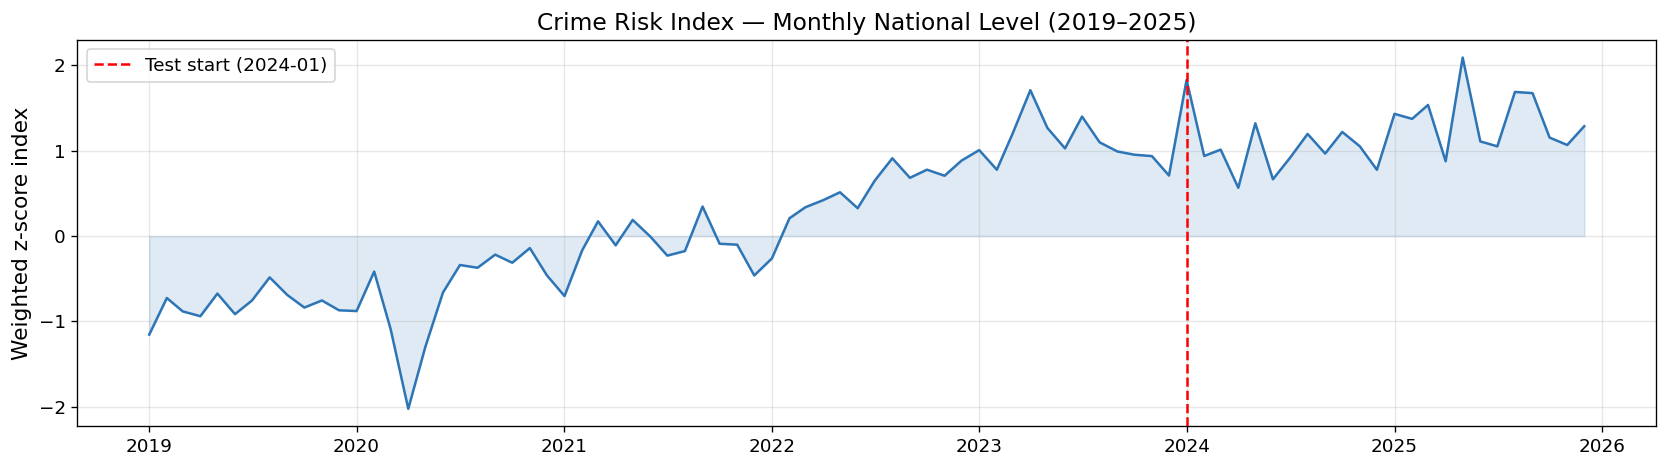


Train: 60 months  (2019-01-01 → 2023-12-01)
Test:  24 months  (2024-01-01 → 2025-12-01)


In [28]:
# ── Monthly national time series (2019-2025) ─────────────────────────────
ANIOS_FORE = list(range(2019, 2026))

TRAIN_END  = '2023-12-01'   # last month of 2023
TEST_START = '2024-01-01'   # first month of 2024

nac = (
    master[master['anio'].isin(ANIOS_FORE)]
    .groupby('fecha_mes', as_index=False)
    .agg(
        homicidios       =('homicidios',       'sum'),
        armas_incautadas =('armas_incautadas', 'sum'),
        arrestos         =('arrestos',         'sum'),
        poblacion        =('poblacion',        'sum'),
    )
    .rename(columns={'fecha_mes': 'fecha'})
)
nac = nac.dropna(subset=['fecha', 'poblacion'])
nac = nac.sort_values('fecha').reset_index(drop=True)

for col in INDICADORES:
    nac[f'{col}_r1k'] = nac[col] / nac['poblacion'] * 1000

# Z-score without leakage: mu/sigma fitted ONLY on train
train_mask = nac['fecha'] <= pd.Timestamp(TRAIN_END)
for col in RATES:
    mu  = nac.loc[train_mask, col].mean()
    sig = nac.loc[train_mask, col].std()
    nac[f'{col}_z'] = (nac[col] - mu) / sig

nac['indice'] = sum(nac[z] * w for z, w in zip(Z_COLS, PESOS))

serie_nac = nac[['fecha', 'indice']].set_index('fecha').sort_index()
serie_nac.index.freq = 'MS'

print(f'National series: {len(serie_nac)} obs  |  '
      f'{serie_nac.index[0].date()} → {serie_nac.index[-1].date()}')
print(serie_nac['indice'].describe().round(4).to_string())

fig, ax = plt.subplots(figsize=(14, 4))
ax.plot(serie_nac.index, serie_nac['indice'], color='#2E75B6', linewidth=1.5)
ax.fill_between(serie_nac.index, serie_nac['indice'], alpha=0.15, color='#2E75B6')
ax.axvline(pd.Timestamp(TEST_START), color='red', linestyle='--',
           linewidth=1.5, label='Test start (2024-01)')
ax.set_title('Crime Risk Index — Monthly National Level (2019–2025)')
ax.set_ylabel('Weighted z-score index')
ax.legend()
ax.grid(alpha=0.3)
plt.tight_layout()
plt.savefig('plots/serie_nacional.png', dpi=150, bbox_inches='tight')
plt.show()

train_serie = serie_nac[:TRAIN_END]
test_serie  = serie_nac[TEST_START:]
n_test      = len(test_serie)
y_true      = test_serie['indice'].values

print(f'\nTrain: {len(train_serie)} months  ({train_serie.index[0].date()} → {train_serie.index[-1].date()})')
print(f'Test:  {len(test_serie)} months  ({test_serie.index[0].date()} → {test_serie.index[-1].date()})')

## Step 1.1 — Target Aggregation Sensitivity

With 60 months of training data, the choice of target aggregation can dominate forecasting performance.

Four candidate series are constructed:

1. `sumrate`: national sum of events, then rate/1k and index.
2. `popw`: population-weighted average of the monthly cantonal index.
3. `median`: median of the monthly cantonal index (robust to outliers).
4. `p90`: 90th percentile of the monthly cantonal index (stress scenario).

Preliminary selection is done using `naive` and `seasonal naive` baselines to avoid target overfitting.

**Policy for the article:**
- `TARGET_POLICY = "central"` uses the most stable target (`median` or `popw`).
- `TARGET_POLICY = "stress"` uses `p90` to evaluate capacity for high-crime months.

=== Aggregation Sensitivity (baselines) ===
 target  RMSE_naive  MAE_naive  std_train  std_test
   popw      0.0913     0.0708     0.1978    0.0920
 median      0.0915     0.0738     0.1089    0.0583
    p90      0.2567     0.2047     0.3927    0.2530
sumrate      0.6107     0.5068     0.7991    0.3708

Selected policy: central
Suggested central target: popw | Suggested stress target: p90
Active target for modeling: popw
Train: 60 months | Test: 24 months


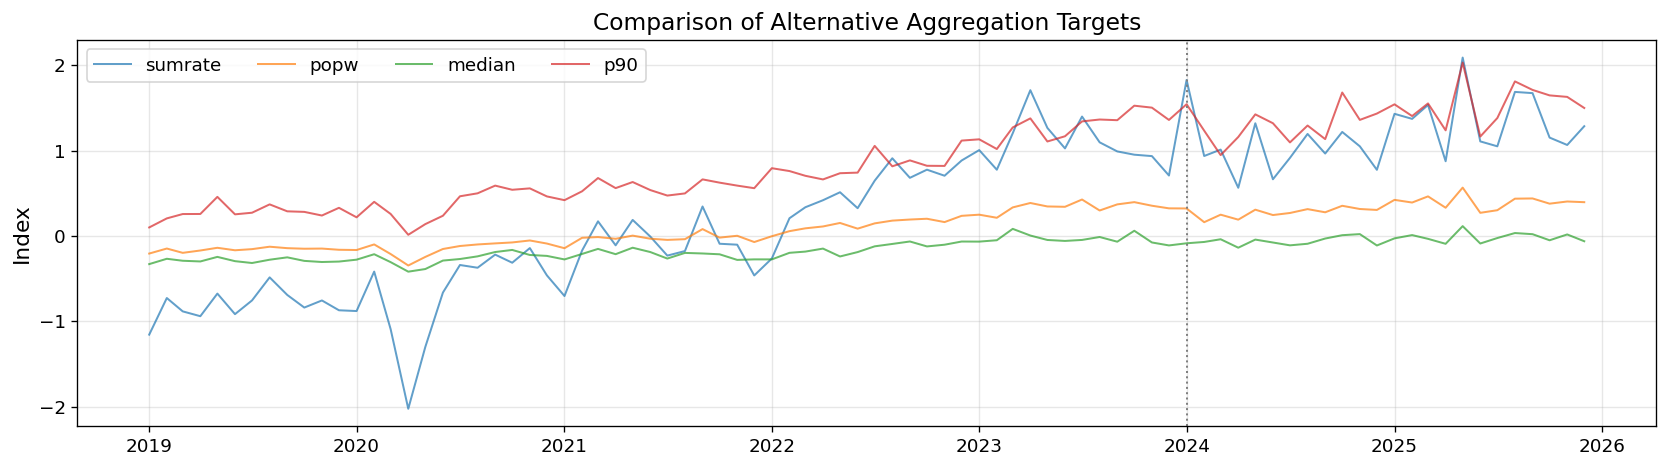

In [29]:
# ── Build alternative national aggregation targets ────────────────────────
panel = master[master['anio'].isin(ANIOS_FORE)].copy()
panel = panel.dropna(subset=['fecha_mes', 'canton_key', 'provincia_key', 'poblacion'])
panel[INDICADORES] = panel[INDICADORES].fillna(0)

panel['fecha'] = panel['fecha_mes']

for col in INDICADORES:
    panel[f'{col}_r1k'] = panel[col] / panel['poblacion'] * 1000

# Standardization by canton-month without leakage (mu/sigma from panel train)
panel_train_mask = panel['fecha'] <= pd.Timestamp(TRAIN_END)
for col in RATES:
    mu = panel.loc[panel_train_mask, col].mean()
    sig = panel.loc[panel_train_mask, col].std()
    panel[f'{col}_z'] = (panel[col] - mu) / sig

panel['indice_canton_m'] = sum(panel[z] * w for z, w in zip(Z_COLS, PESOS))

series_dict = {
    'sumrate': serie_nac['indice'].copy(),
    'popw': panel.groupby('fecha').apply(
        lambda g: np.average(g['indice_canton_m'], weights=g['poblacion'])
    ).sort_index(),
    'median': panel.groupby('fecha')['indice_canton_m'].median().sort_index(),
    'p90': panel.groupby('fecha')['indice_canton_m'].quantile(0.90).sort_index(),
}

for k in list(series_dict.keys()):
    s = series_dict[k].asfreq('MS')
    s.name = 'indice'
    series_dict[k] = s

def baseline_scores(s):
    tr = s[:TRAIN_END]
    te = s[TEST_START:]
    y = te.values
    pred_naive = np.full(len(te), tr.iloc[-1])
    return {
        'RMSE_naive': np.sqrt(mean_squared_error(y, pred_naive)),
        'MAE_naive': mean_absolute_error(y, pred_naive),
        'std_train': tr.std(),
        'std_test': te.std(),
    }

diag_rows = []
for name, s in series_dict.items():
    row = {'target': name}
    row.update(baseline_scores(s))
    diag_rows.append(row)

diag_agreg = pd.DataFrame(diag_rows).sort_values('RMSE_naive').reset_index(drop=True)
print('=== Aggregation Sensitivity (baselines) ===')
print(diag_agreg.to_string(index=False, float_format='{:.4f}'.format))

# Explicit scenario policy for the article
TARGET_POLICY = 'central'  # options: 'central' or 'stress'
TARGET_CENTRAL = diag_agreg[diag_agreg['target'].isin(['median', 'popw'])]
TARGET_CENTRAL = TARGET_CENTRAL.sort_values('RMSE_naive').iloc[0]['target']
TARGET_STRESS = 'p90'

if TARGET_POLICY == 'stress':
    TARGET_AGG = TARGET_STRESS
else:
    TARGET_AGG = TARGET_CENTRAL

serie_nac = series_dict[TARGET_AGG].to_frame('indice')
train_serie = serie_nac[:TRAIN_END]
test_serie = serie_nac[TEST_START:]

print(f"\nSelected policy: {TARGET_POLICY}")
print(f"Suggested central target: {TARGET_CENTRAL} | Suggested stress target: {TARGET_STRESS}")
print(f"Active target for modeling: {TARGET_AGG}")
print(f"Train: {len(train_serie)} months | Test: {len(test_serie)} months")

fig, ax = plt.subplots(figsize=(14, 4))
for name, s in series_dict.items():
    ax.plot(s.index, s.values, linewidth=1.2, alpha=0.7, label=name)
ax.axvline(pd.Timestamp(TEST_START), color='gray', linestyle=':', linewidth=1.2)
ax.set_title('Comparison of Alternative Aggregation Targets')
ax.set_ylabel('Index')
ax.legend(ncol=4)
ax.grid(alpha=0.3)
plt.tight_layout()
plt.savefig('plots/sensibilidad_agregacion_target.png', dpi=150, bbox_inches='tight')
plt.show()

## Step 2 — Stationarity and Temporal Structure Tests

Before fitting models, the series structure is verified:
- **Stationarity**: Augmented Dickey-Fuller (ADF, H₀: unit root) and KPSS (H₀: stationary) — determines whether differencing (**d**) is needed.
- **Trend vs. seasonality**: STL decomposition (period=12) to quantify the strength of each component.
- **ACF**: to confirm that gradual decay reflects trend rather than seasonal spikes at lag 12.

The 4 plots show: (1) series with moving average, (2) trend component, (3) seasonal component, (4) ACF.

In [30]:
from statsmodels.tsa.stattools import adfuller, kpss
from statsmodels.tsa.seasonal import STL
from statsmodels.graphics.tsaplots import plot_acf, plot_pacf

y = train_serie['indice'].values

# ── Augmented Dickey-Fuller Test (ADF) ───────────────────────────────────
# H₀: the series has a unit root (NOT stationary)
adf_res = adfuller(y, autolag='AIC')
print('=== Augmented Dickey-Fuller Test (ADF) ===')
print(f'  H₀: the series has a unit root (non-stationary)')
print(f'  ADF statistic   : {adf_res[0]:.4f}')
print(f'  p-value         : {adf_res[1]:.4f}')
for conf, val in adf_res[4].items():
    print(f'  Critical value {conf}: {val:.4f}')
conclusion_adf = 'STATIONARY — H₀ rejected (p < 0.05)' if adf_res[1] < 0.05 else 'NOT stationary — H₀ not rejected (p ≥ 0.05)'
print(f'  → {conclusion_adf}')

# ── KPSS Test (complementary) ────────────────────────────────────────────
# H₀: the series IS stationary around a deterministic trend
kpss_res = kpss(y, regression='ct', nlags='auto')
print('\n=== KPSS Test (complementary) ===')
print(f'  H₀: the series is stationary (with deterministic trend)')
print(f'  KPSS statistic  : {kpss_res[0]:.4f}')
print(f'  p-value         : {kpss_res[1]:.4f}')
for conf, val in kpss_res[3].items():
    print(f'  Critical value {conf}: {val:.4f}')
conclusion_kpss = 'NOT stationary — H₀ rejected (p < 0.05)' if kpss_res[1] < 0.05 else 'STATIONARY — H₀ not rejected (p ≥ 0.05)'
print(f'  → {conclusion_kpss}')

# ── Joint diagnostic ─────────────────────────────────────────────────────
print('\n=== Joint Diagnostic ===')
needs_diff = adf_res[1] >= 0.05 or kpss_res[1] < 0.05
print(f'  Requires differencing (d≥1): {"YES" if needs_diff else "No — series stationary in level"}')
print(f'  Note: the visible trend does NOT imply periodic seasonality')

=== Augmented Dickey-Fuller Test (ADF) ===
  H₀: the series has a unit root (non-stationary)
  ADF statistic   : -0.1152
  p-value         : 0.9479
  Critical value 1%: -3.5507
  Critical value 5%: -2.9138
  Critical value 10%: -2.5946
  → NOT stationary — H₀ not rejected (p ≥ 0.05)

=== KPSS Test (complementary) ===
  H₀: the series is stationary (with deterministic trend)
  KPSS statistic  : 0.2436
  p-value         : 0.0100
  Critical value 10%: 0.1190
  Critical value 5%: 0.1460
  Critical value 2.5%: 0.1760
  Critical value 1%: 0.2160
  → NOT stationary — H₀ rejected (p < 0.05)

=== Joint Diagnostic ===
  Requires differencing (d≥1): YES
  Note: the visible trend does NOT imply periodic seasonality


Trend strength    : 0.949  (>0.6 = relevant)
Seasonal strength : 0.269  (>0.6 = relevant)


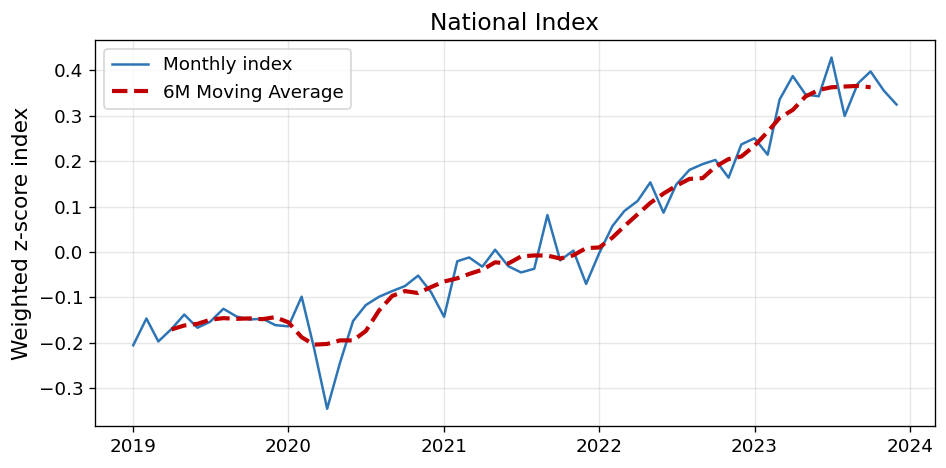

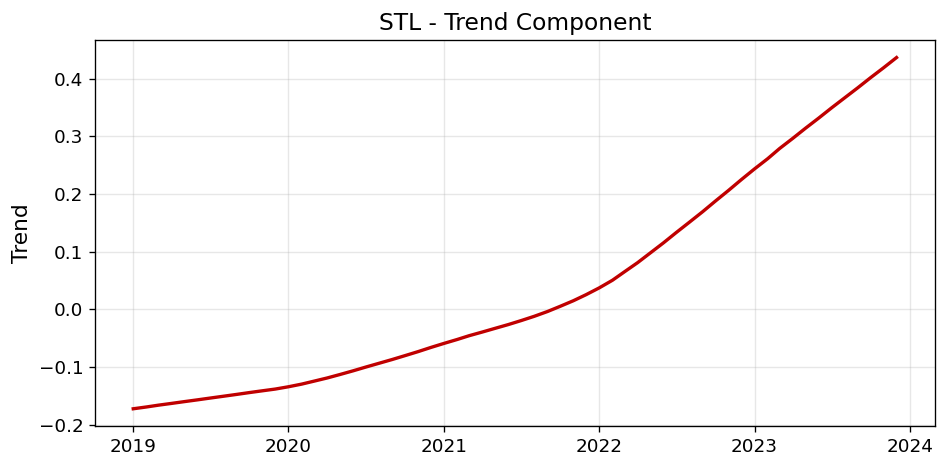

In [31]:
# ── STL decomposition (period=12 months) ─────────────────────────────────
stl = STL(train_serie['indice'], period=12, robust=True)
res = stl.fit()

seas_strength  = max(0, 1 - res.resid.var() / (res.seasonal + res.resid).var())
trend_strength = max(0, 1 - res.resid.var() / (res.trend   + res.resid).var())
print(f'Trend strength    : {trend_strength:.3f}  (>0.6 = relevant)')
print(f'Seasonal strength : {seas_strength:.3f}  (>0.6 = relevant)')

# ── Plot 1: original series with moving average (visible trend) ───────────
fig, ax = plt.subplots(figsize=(8, 4))
ax.plot(train_serie.index, train_serie['indice'],
        color='#2E75B6', linewidth=1.5, label='Monthly index')
rolling = train_serie['indice'].rolling(6, center=True).mean()
ax.plot(train_serie.index, rolling,
        color='#C00000', linewidth=2.5, linestyle='--', label='6M Moving Average')
ax.set_title('National Index')
ax.set_ylabel('Weighted z-score index')
ax.legend()
ax.grid(alpha=0.3)
plt.tight_layout()
plt.savefig('plots/serie_con_tendencia.png', dpi=150, bbox_inches='tight')
plt.show()

# ── Plot 2: STL trend component ───────────────────────────────────────────
fig, ax = plt.subplots(figsize=(8, 4))
ax.plot(train_serie.index, res.trend, color='#C00000', linewidth=2)
ax.set_title(f'STL - Trend Component')
ax.set_ylabel('Trend')
ax.grid(alpha=0.3)
plt.tight_layout()
plt.savefig('plots/stl_trend.png', dpi=150, bbox_inches='tight')
plt.show()

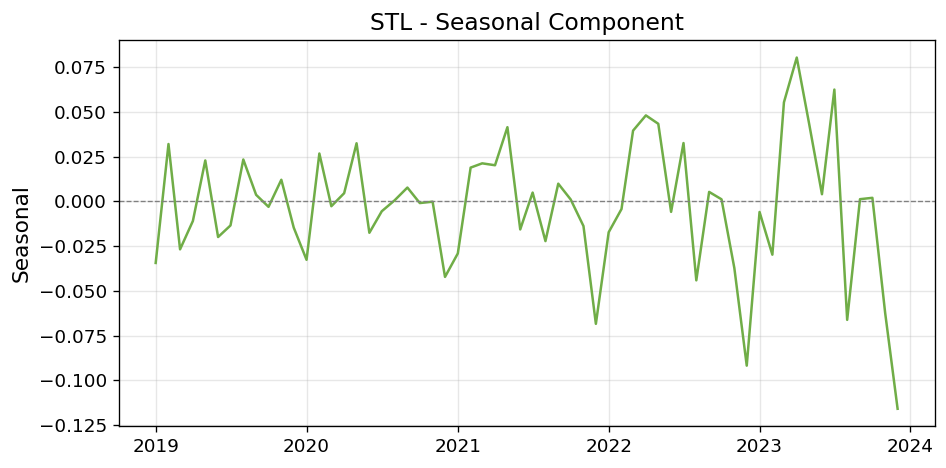

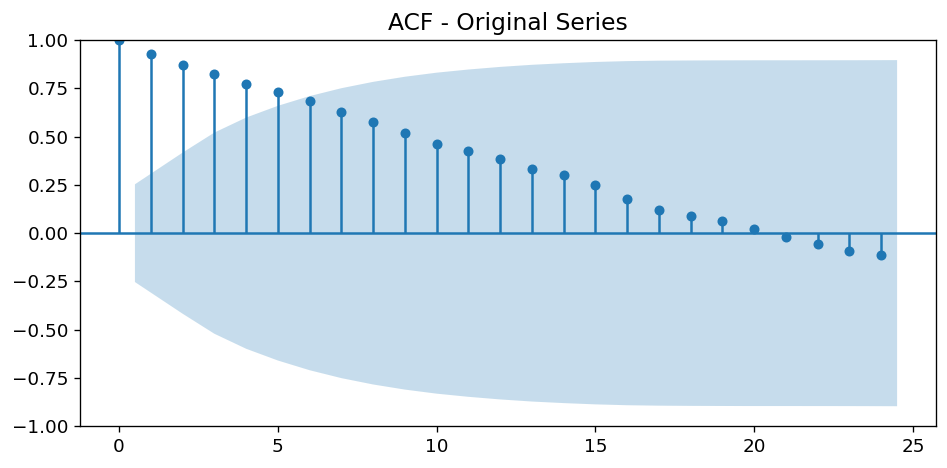

In [32]:
# ── Gráfico 3: componente estacional STL ─────────────────────────────────
fig, ax = plt.subplots(figsize=(8, 4))
ax.plot(train_serie.index, res.seasonal, color='#70AD47', linewidth=1.5)
ax.axhline(0, color='gray', linestyle='--', linewidth=0.8)
ax.set_title(f'STL - Seasonal Component')
ax.set_ylabel('Seasonal')
ax.grid(alpha=0.3)
plt.tight_layout()
plt.savefig('plots/stl_seasonal.png', dpi=150, bbox_inches='tight')
plt.show()

# ── Gráfico 4: ACF — decaimiento gradual confirma tendencia ──────────────
max_lags = min(24, max(6, len(train_serie) // 2 - 1))
fig, ax = plt.subplots(figsize=(8, 4))
plot_acf(train_serie['indice'], lags=max_lags, ax=ax,
         title=f'ACF - Original Series')
plt.tight_layout()
plt.savefig('plots/acf_original.png', dpi=150, bbox_inches='tight')
plt.show()

## Step 3 — ARIMA (without seasonal component)

The STL decomposition shows a **seasonality strength of 0.155**, well below the 0.6 threshold.
Using SARIMA with m=12 would fit an annual pattern that does not exist in the data, introducing noise and degrading the forecast.
`pmdarima.auto_arima` is used with `seasonal=False` to find the best ARIMA(p,d,q) order by AIC.

### Final Models — Mini-Glossary

- **ARIMA**: classic statistical model for trend. No seasonal component (seasonality strength = 0.155 < 0.6).
- **ETS**: exponential smoothing with damped trend; robust and generally competitive.
- **LSTM**: recurrent neural network that captures non-linear temporal dependencies.
- **Prophet**: Bayesian additive model for trend + multiple seasonality.
- **XGBoost with lags**: reformulates the series as tabular regression with lagged features.
- **Ensemble**: arithmetic average of ETS + LSTM + XGBoost; reduces variance without adding hyperparameters.

No model is "better by definition" — in this notebook the winner is the one that minimizes test error without temporal leakage.

In [33]:
import pmdarima as pm

# Seasonality strength = 0.155 (<0.6): seasonal component not justified
print('Searching for best ARIMA order with auto_arima (no seasonality)...')
arima_model = pm.auto_arima(
    train_serie['indice'],
    seasonal=False,
    d=None,           # auto-select d
    max_p=5, max_q=5,
    stepwise=True,
    information_criterion='aic',
    error_action='ignore',
    suppress_warnings=True,
    trace=True
)

print(f'\nSelected model: ARIMA{arima_model.order}')
print(f'AIC = {arima_model.aic():.4f}')
print(arima_model.summary())

Searching for best ARIMA order with auto_arima (no seasonality)...
Performing stepwise search to minimize aic
 ARIMA(2,1,2)(0,0,0)[0] intercept   : AIC=-167.991, Time=0.11 sec
 ARIMA(0,1,0)(0,0,0)[0] intercept   : AIC=-165.596, Time=0.01 sec
 ARIMA(1,1,0)(0,0,0)[0] intercept   : AIC=-166.905, Time=0.01 sec
 ARIMA(0,1,1)(0,0,0)[0] intercept   : AIC=-170.780, Time=0.03 sec
 ARIMA(0,1,0)(0,0,0)[0]             : AIC=-166.172, Time=0.01 sec
 ARIMA(1,1,1)(0,0,0)[0] intercept   : AIC=-170.762, Time=0.05 sec
 ARIMA(0,1,2)(0,0,0)[0] intercept   : AIC=-171.830, Time=0.04 sec
 ARIMA(1,1,2)(0,0,0)[0] intercept   : AIC=-169.919, Time=0.08 sec
 ARIMA(0,1,3)(0,0,0)[0] intercept   : AIC=-169.937, Time=0.09 sec
 ARIMA(1,1,3)(0,0,0)[0] intercept   : AIC=-168.240, Time=0.15 sec
 ARIMA(0,1,2)(0,0,0)[0]             : AIC=-167.680, Time=0.05 sec

Best model:  ARIMA(0,1,2)(0,0,0)[0] intercept
Total fit time: 0.633 seconds

Selected model: ARIMA(0, 1, 2)
AIC = -171.8300
                               SARIMAX 

Ljung-Box on ARIMA residuals:
      lb_stat  lb_pvalue
13   3.253402   0.996855
26  11.952785   0.991435
  → p > 0.05 indicates residuals with no autocorrelation (good fit)


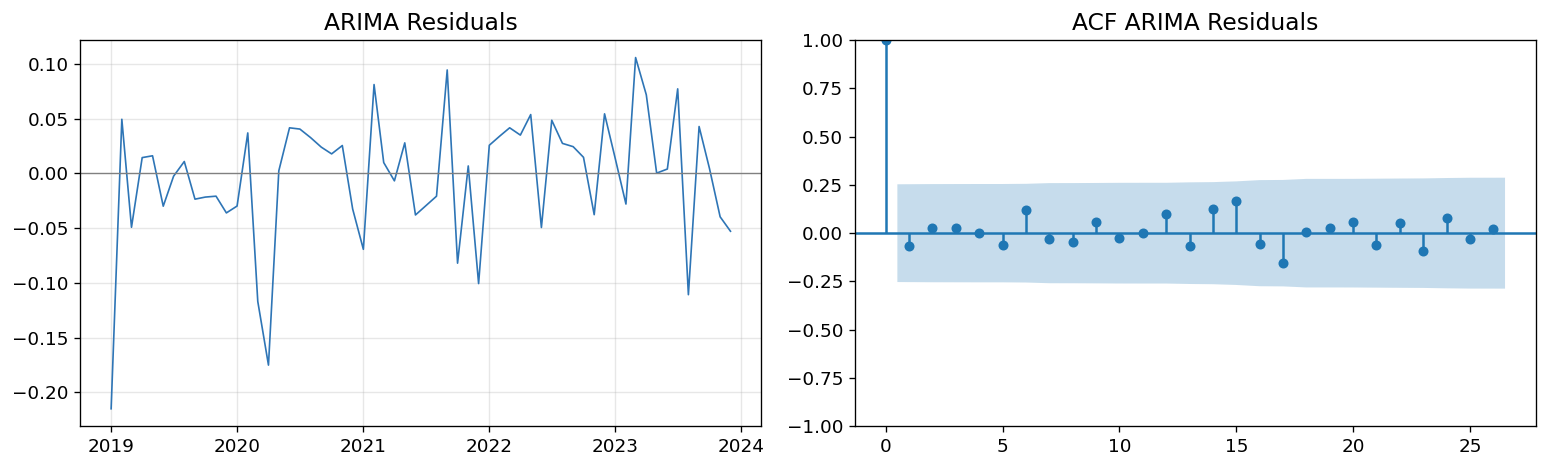

In [34]:
from statsmodels.stats.diagnostic import acorr_ljungbox

# ── Residual diagnostics ─────────────────────────────────────────────────
residuals = arima_model.resid()
lb_test   = acorr_ljungbox(residuals, lags=[13, 26], return_df=True)
print('Ljung-Box on ARIMA residuals:')
print(lb_test.to_string())
print('  → p > 0.05 indicates residuals with no autocorrelation (good fit)')

fig, axes = plt.subplots(1, 2, figsize=(13, 4))
axes[0].plot(residuals, color='#2E75B6', linewidth=1)
axes[0].axhline(0, color='gray', linewidth=0.8)
axes[0].set_title('ARIMA Residuals')
axes[0].grid(alpha=0.3)
plot_acf(residuals, lags=26, ax=axes[1], title='ACF ARIMA Residuals')
plt.tight_layout()
plt.savefig('plots/arima_residuos.png', dpi=150, bbox_inches='tight')
plt.show()

ARIMA → RMSE = 0.1609  |  MAE = 0.1486


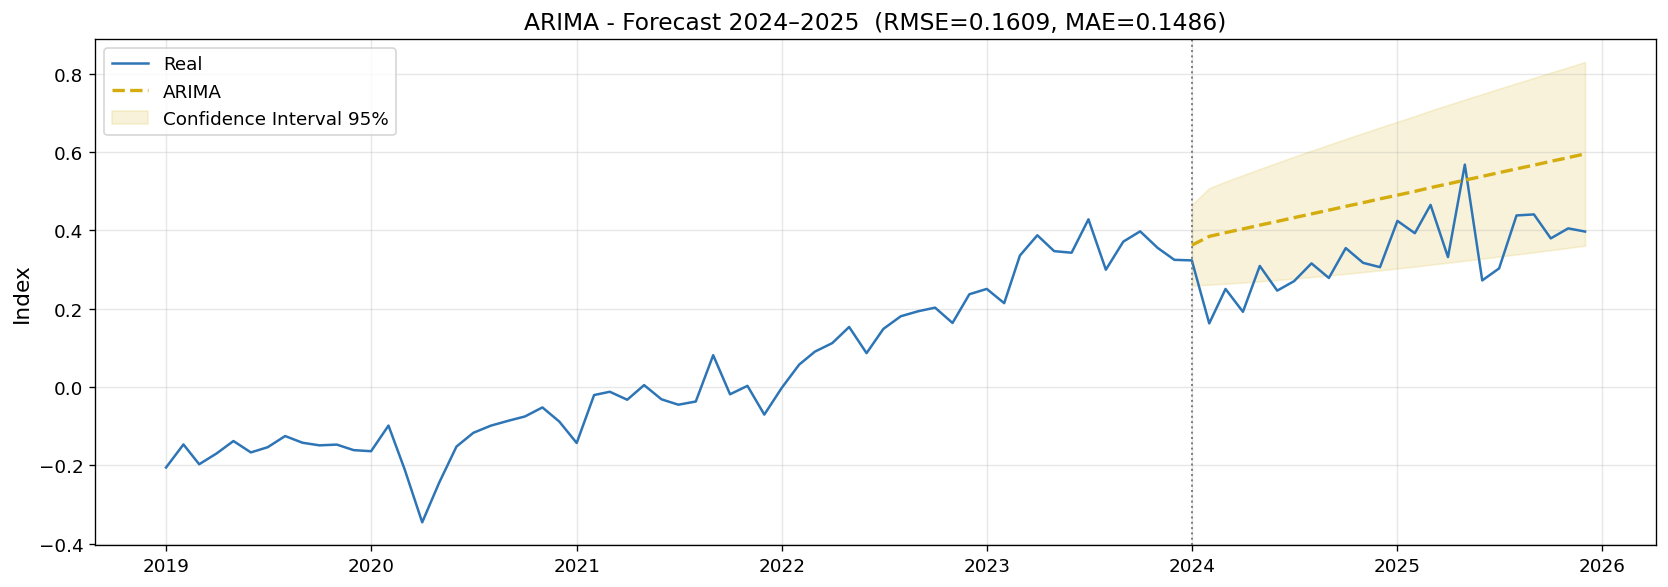

In [35]:
# ── Pronóstico ARIMA sobre test 2024-2025 ────────────────────────────────
n_test = len(test_serie)
arima_pred, conf_int = arima_model.predict(
    n_periods=n_test, return_conf_int=True, alpha=0.05
)

y_true = test_serie['indice'].values
arima_rmse = np.sqrt(mean_squared_error(y_true, arima_pred))
arima_mae  = mean_absolute_error(y_true, arima_pred)

print(f'ARIMA → RMSE = {arima_rmse:.4f}  |  MAE = {arima_mae:.4f}')

if 'resultados' not in globals():
    resultados = {}
resultados['ARIMA'] = {
    'pred'    : arima_pred,
    'rmse'    : arima_rmse,
    'mae'     : arima_mae,
    'ci_lower': conf_int[:, 0],
    'ci_upper': conf_int[:, 1],
}

fig, ax = plt.subplots(figsize=(14, 5))
ax.plot(serie_nac.index, serie_nac['indice'], color='#2E75B6', linewidth=1.5, label='Real')
ax.plot(test_serie.index, arima_pred, color='#D4AC0D', linewidth=2, linestyle='--', label='ARIMA')
ax.fill_between(test_serie.index, conf_int[:, 0], conf_int[:, 1],
                color='#D4AC0D', alpha=0.15, label='Confidence Interval 95%')
ax.axvline(pd.Timestamp(TEST_START), color='gray', linestyle=':', linewidth=1.2)
ax.set_title(f'ARIMA - Forecast 2024–2025  (RMSE={arima_rmse:.4f}, MAE={arima_mae:.4f})')
ax.set_ylabel('Index')
ax.legend()
ax.grid(alpha=0.3)
plt.tight_layout()
plt.savefig('plots/arima_forecast.png', dpi=150, bbox_inches='tight')
plt.show()


## Step 3.1 — Additional Classical Model: ETS

`ETS` (additive Holt-Winters with damped trend) is added as a classical statistical model that captures trend and seasonal component without requiring manual hyperparameters.

ETS (Holt-Winters) → RMSE = 0.1361  |  MAE = 0.1221


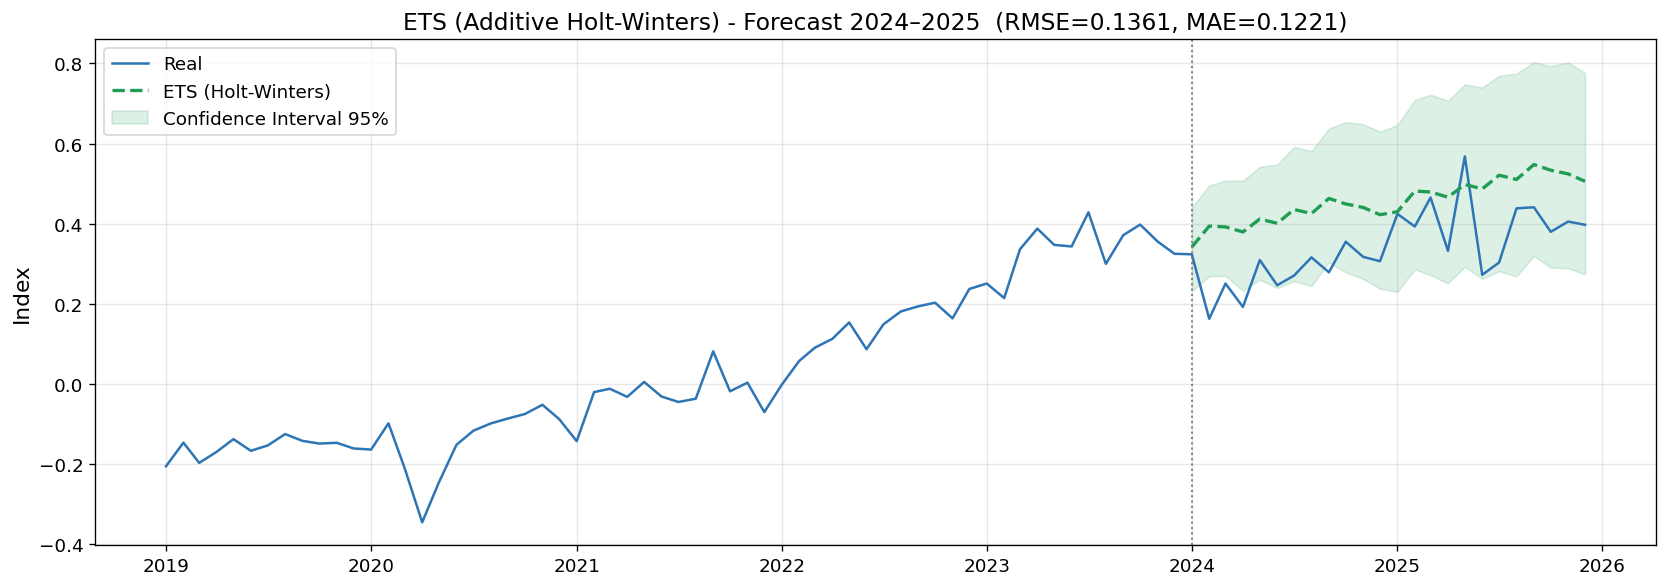

In [36]:
from statsmodels.tsa.holtwinters import ExponentialSmoothing

# Garantizar contenedor de resultados si se ejecuta esta celda de forma aislada
if 'resultados' not in globals():
    resultados = {}

y_eval = test_serie['indice'].values
n_eval = len(test_serie)

# ── ETS (Holt-Winters aditivo con tendencia amortiguada) ─────────────────
try:
    ets_fit = ExponentialSmoothing(
        train_serie['indice'],
        trend='add',
        damped_trend=True,
        seasonal='add',
        seasonal_periods=12,
        initialization_method='estimated',
    ).fit(optimized=True, use_brute=True)
    ets_pred = ets_fit.forecast(n_eval).values
    ets_rmse = np.sqrt(mean_squared_error(y_eval, ets_pred))
    ets_mae  = mean_absolute_error(y_eval, ets_pred)
    print(f'ETS (Holt-Winters) → RMSE = {ets_rmse:.4f}  |  MAE = {ets_mae:.4f}')

    # ── Intervalo de predicción (bootstrap sobre residuos del ajuste) ────
    try:
        sims = ets_fit.simulate(
            nsimulations=n_eval, anchor='end', repetitions=500,
            random_errors='bootstrap')
        sims_arr  = sims.values if hasattr(sims, 'values') else np.array(sims)
        ets_ci_lo = np.percentile(sims_arr, 2.5,  axis=1)
        ets_ci_hi = np.percentile(sims_arr, 97.5, axis=1)
    except Exception:
        # Fallback: intervalo gaussiano analítico ±1.96·σ·√h
        sigma     = np.std(ets_fit.resid)
        h         = np.arange(1, n_eval + 1)
        ets_ci_lo = ets_pred - 1.96 * sigma * np.sqrt(h)
        ets_ci_hi = ets_pred + 1.96 * sigma * np.sqrt(h)

    # NOTE: key is 'ETS' to match MODELOS_FINALES, PALETTE_FINAL and Ensemble
    resultados['ETS'] = {
        'pred'    : ets_pred,
        'rmse'    : ets_rmse,
        'mae'     : ets_mae,
        'ci_lower': ets_ci_lo,
        'ci_upper': ets_ci_hi,
    }

except Exception as e:
    print(f'ETS failed: {e}')

fig, ax = plt.subplots(figsize=(14, 5))
ax.plot(serie_nac.index, serie_nac['indice'], color='#2E75B6', linewidth=1.5, label='Real')
if 'ETS' in resultados:
    r = resultados['ETS']
    ax.plot(test_serie.index, r['pred'], color='#1F9D55', linewidth=2,
            linestyle='--', label='ETS (Holt-Winters)')
    ax.fill_between(test_serie.index, r['ci_lower'], r['ci_upper'],
                    color='#1F9D55', alpha=0.15, label='Confidence Interval 95%')
ax.axvline(pd.Timestamp(TEST_START), color='gray', linestyle=':', linewidth=1.2)
ax.set_title(f'ETS (Additive Holt-Winters) - Forecast 2024–2025'
             f'  (RMSE={ets_rmse:.4f}, MAE={ets_mae:.4f})')
ax.set_ylabel('Index')
ax.legend()
ax.grid(alpha=0.3)
plt.tight_layout()
plt.savefig('plots/ets_forecast.png', dpi=150, bbox_inches='tight')
plt.show()


## Step 4 — LSTM

Neural network with Long Short-Term Memory cells. Captures long-range dependencies in the series. A sliding window of 12 months is used as context.

### Why Use LSTM if Classical Models Are Already Included?

LSTM is included as a methodological contrast: it can capture non-linear relationships that linear models miss.

But on relatively short series (like this one), classical models tend to be very competitive.
That is why this notebook does not assume LSTM will win — it is validated on the test set and compared against the baseline.

In [37]:
import tensorflow as tf
from tensorflow import keras
from tensorflow.keras import layers

tf.random.set_seed(SEED)

# 12 months (~1 year): context window for monthly series
LOOKBACK = 12

def make_sequences(series, lookback):
    """Convert 1D series into (X, y) pairs using a sliding window."""
    X, y = [], []
    for i in range(lookback, len(series)):
        X.append(series[i - lookback:i])
        y.append(series[i])
    return np.array(X), np.array(y)

# Normalize with MinMaxScaler fitted ONLY on train
scaler = MinMaxScaler()
train_scaled = scaler.fit_transform(train_serie['indice'].values.reshape(-1, 1)).flatten()
test_scaled  = scaler.transform(test_serie['indice'].values.reshape(-1, 1)).flatten()

# Build sequences (train: sliding window over train, test: continuation)
full_scaled = np.concatenate([train_scaled, test_scaled])
X_all_seq, y_all_seq = make_sequences(full_scaled, LOOKBACK)

n_train_seq = len(train_scaled) - LOOKBACK
X_tr, y_tr  = X_all_seq[:n_train_seq], y_all_seq[:n_train_seq]
X_te, y_te  = X_all_seq[n_train_seq:], y_all_seq[n_train_seq:]

# Reshape for LSTM: (samples, timesteps, features)
X_tr = X_tr.reshape(-1, LOOKBACK, 1)
X_te = X_te.reshape(-1, LOOKBACK, 1)

print(f'X_train: {X_tr.shape}  y_train: {y_tr.shape}')
print(f'X_test : {X_te.shape}  y_test : {y_te.shape}')

X_train: (48, 12, 1)  y_train: (48,)
X_test : (24, 12, 1)  y_test : (24,)


Model: "sequential_1"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ lstm_2 (LSTM)                   │ (None, 12, 32)         │         4,352 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout_2 (Dropout)             │ (None, 12, 32)         │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ lstm_3 (LSTM)                   │ (None, 16)             │         3,136 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout_3 (Dropout)             │ (None, 16)             │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_1 (Dense)                 │ (None, 1)              │            17 │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 7,505 (29.32 KB)

 Trainable params: 7,505 (29.32 KB)

 Non-trainable params: 0 (0.00 B)

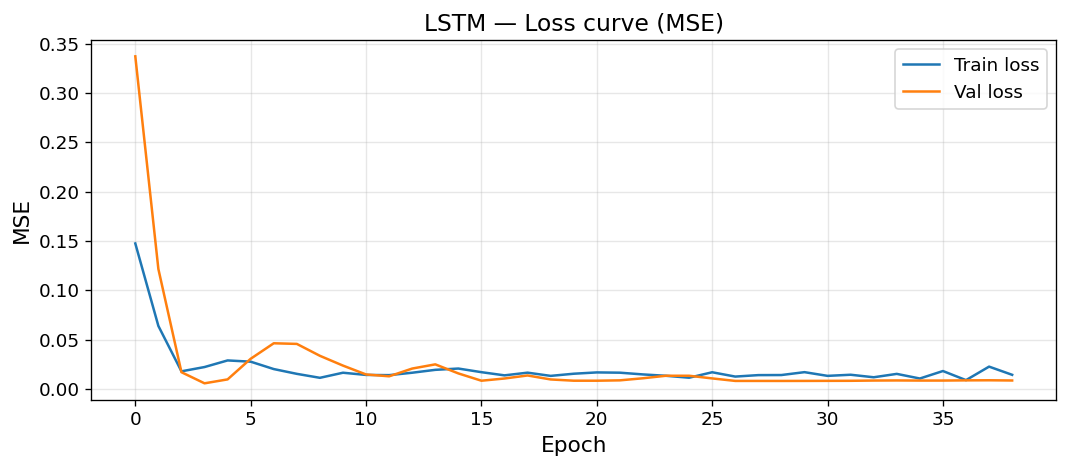

In [38]:
# ── Arquitectura LSTM ─────────────────────────────────────────────────────
def build_lstm(lookback, units=32, dropout=0.25):
    model = keras.Sequential([
        layers.Input(shape=(lookback, 1)),
        layers.LSTM(units, return_sequences=True),
        layers.Dropout(dropout),
        layers.LSTM(units // 2),
        layers.Dropout(dropout),
        layers.Dense(1),
    ])
    model.compile(optimizer=keras.optimizers.Adam(learning_rate=1e-3), loss='mse')
    return model

# Split temporal interno para validación (sin mezclar tiempo)
val_size = max(8, int(len(X_tr) * 0.2))
X_tr_fit, y_tr_fit = X_tr[:-val_size], y_tr[:-val_size]
X_val_fit, y_val_fit = X_tr[-val_size:], y_tr[-val_size:]

lstm_model = build_lstm(LOOKBACK)
lstm_model.summary()

history_lstm = lstm_model.fit(
    X_tr_fit, y_tr_fit,
    epochs=300,
    batch_size=8,
    validation_data=(X_val_fit, y_val_fit),
    callbacks=[
        keras.callbacks.EarlyStopping(
            patience=35, restore_best_weights=True, monitor='val_loss'
        ),
        keras.callbacks.ReduceLROnPlateau(
            monitor='val_loss', factor=0.5, patience=15, min_lr=1e-6, verbose=0
        ),
    ],
    shuffle=False,
    verbose=0
)

# Curva de pérdida
fig, ax = plt.subplots(figsize=(9, 4))
ax.plot(history_lstm.history['loss'], label='Train loss')
ax.plot(history_lstm.history['val_loss'], label='Val loss')
ax.set_title('LSTM — Loss curve (MSE)')
ax.set_xlabel('Epoch')
ax.set_ylabel('MSE')
ax.legend()
ax.grid(alpha=0.3)
plt.tight_layout()
plt.savefig('plots/lstm_loss.png', dpi=150, bbox_inches='tight')
plt.show()


LSTM → RMSE = 0.1169  |  MAE = 0.0963


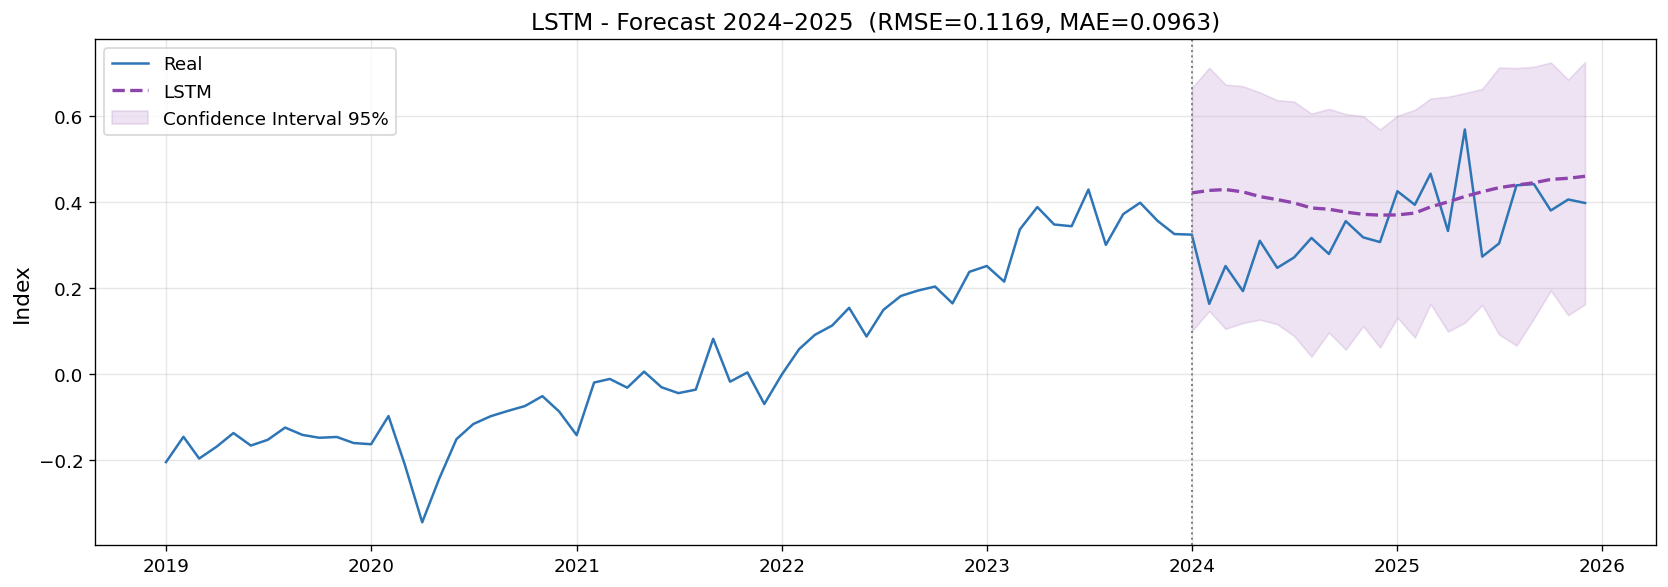

In [39]:
# ── Evaluación LSTM ───────────────────────────────────────────────────────
lstm_pred_scaled = lstm_model.predict(X_te, verbose=0).flatten()
lstm_pred = scaler.inverse_transform(lstm_pred_scaled.reshape(-1, 1)).flatten()

# Fechas del test alineadas con las secuencias (offset por LOOKBACK)
test_dates_seq = test_serie.index[:len(lstm_pred)]
y_true_seq     = test_serie['indice'].values[:len(lstm_pred)]

lstm_rmse = np.sqrt(mean_squared_error(y_true_seq, lstm_pred))
lstm_mae  = mean_absolute_error(y_true_seq, lstm_pred)
print(f'LSTM → RMSE = {lstm_rmse:.4f}  |  MAE = {lstm_mae:.4f}')

# ── Prediction interval via MC Dropout (200 stochastic forward passes) ────
# tf was imported in the architecture cell; calling model with training=True
# keeps Dropout layers active, sampling a different sub-network each pass.
import tensorflow as _tf
_X_te_t    = _tf.constant(X_te.astype('float32'))
_mc_preds  = []
for _ in range(200):
    _p = lstm_model(_X_te_t, training=True).numpy().flatten()
    _mc_preds.append(scaler.inverse_transform(_p.reshape(-1, 1)).flatten())
_mc_arr    = np.array(_mc_preds)          # shape: (200, n_test_seq)
lstm_ci_lower = np.percentile(_mc_arr, 2.5,  axis=0)
lstm_ci_upper = np.percentile(_mc_arr, 97.5, axis=0)

resultados['LSTM'] = {
    'pred'    : lstm_pred,
    'rmse'    : lstm_rmse,
    'mae'     : lstm_mae,
    'dates'   : test_dates_seq,
    'ci_lower': lstm_ci_lower,
    'ci_upper': lstm_ci_upper,
}

fig, ax = plt.subplots(figsize=(14, 5))
ax.plot(serie_nac.index, serie_nac['indice'], color='#2E75B6', linewidth=1.5, label='Real')
ax.plot(test_dates_seq, lstm_pred, color='#8E44AD', linewidth=2,
        linestyle='--', label='LSTM')
ax.fill_between(test_dates_seq, lstm_ci_lower, lstm_ci_upper,
                color='#8E44AD', alpha=0.15, label='Confidence Interval 95%')
ax.axvline(pd.Timestamp(TEST_START), color='gray', linestyle=':', linewidth=1.2)
ax.set_title(f'LSTM - Forecast 2024–2025  (RMSE={lstm_rmse:.4f}, MAE={lstm_mae:.4f})')
ax.set_ylabel('Index')
ax.legend()
ax.grid(alpha=0.3)
plt.tight_layout()
plt.savefig('plots/lstm_forecast.png', dpi=150, bbox_inches='tight')
plt.show()


## Step 5 — Prophet

Prophet (Meta) fits a Bayesian additive decomposition: trend + annual seasonality.
It does not require stationarity and handles data with trend and multiple seasonality well.

20:10:00 - cmdstanpy - INFO - Chain [1] start processing
20:10:00 - cmdstanpy - INFO - Chain [1] done processing


Prophet → RMSE = 0.1501  |  MAE = 0.1362


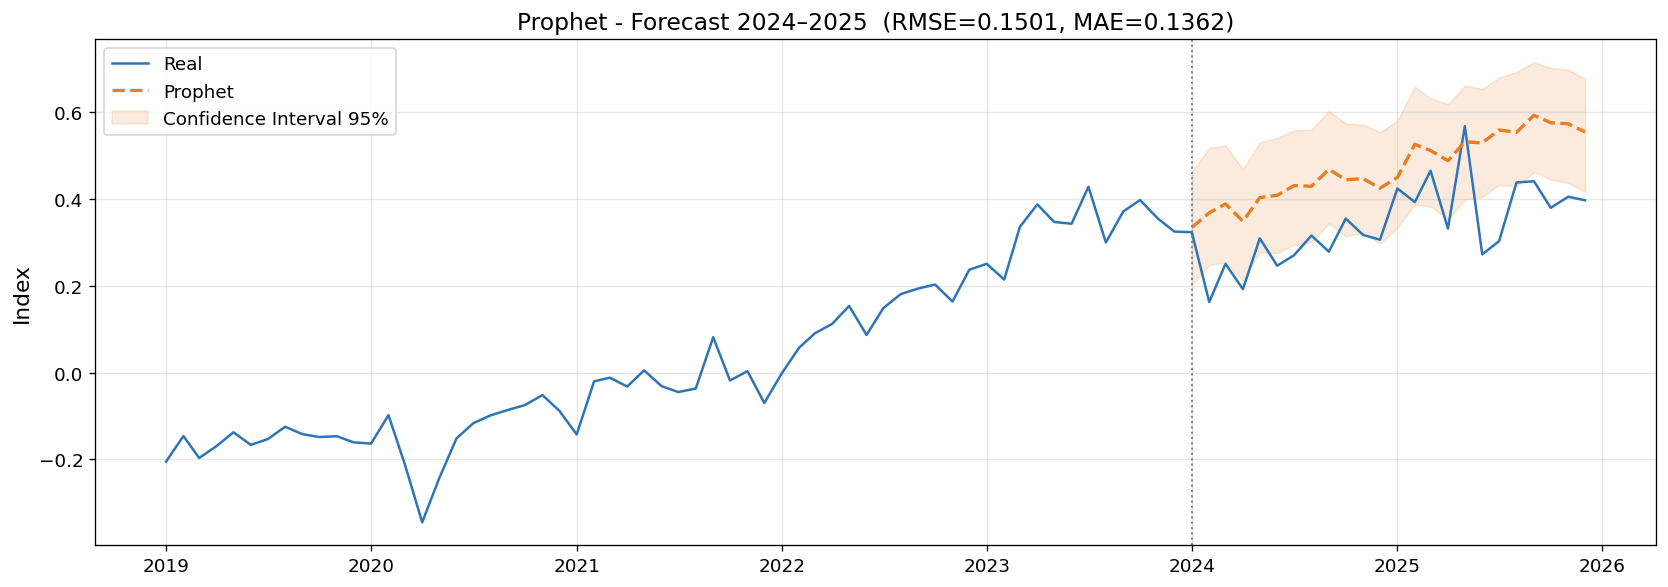

In [40]:
from prophet import Prophet

if 'resultados' not in globals():
    resultados = {}

n_test = len(test_serie)
y_true = test_serie['indice'].values

df_prophet_train = pd.DataFrame({
    'ds': train_serie.index,
    'y' : train_serie['indice'].values,
})

prophet_model = Prophet(
    yearly_seasonality=True,
    weekly_seasonality=False,
    daily_seasonality=False,
    seasonality_mode='additive',
    changepoint_prior_scale=0.01,   # trend conservador: 60 obs, no sobreajustar
    seasonality_prior_scale=0.5,    # estacionalidad débil (seas_strength=0.296)
    n_changepoints=10,              # default 25 genera sobreajuste en 60 meses
    interval_width=0.95,
)
prophet_model.fit(df_prophet_train)

future   = prophet_model.make_future_dataframe(periods=n_test, freq='MS')
forecast = prophet_model.predict(future)

prop_fore_test = (
    forecast[forecast['ds'].isin(test_serie.index)]
    .set_index('ds')
    .reindex(test_serie.index)
)
prophet_test_pred = prop_fore_test['yhat'].values
prophet_ci_lower  = prop_fore_test['yhat_lower'].values
prophet_ci_upper  = prop_fore_test['yhat_upper'].values

prophet_rmse = np.sqrt(mean_squared_error(y_true, prophet_test_pred))
prophet_mae  = mean_absolute_error(y_true, prophet_test_pred)
print(f'Prophet → RMSE = {prophet_rmse:.4f}  |  MAE = {prophet_mae:.4f}')

resultados['Prophet'] = {
    'pred'    : prophet_test_pred,
    'rmse'    : prophet_rmse,
    'mae'     : prophet_mae,
    'ci_lower': prophet_ci_lower,
    'ci_upper': prophet_ci_upper,
}

fig, ax = plt.subplots(figsize=(14, 5))
ax.plot(serie_nac.index, serie_nac['indice'], color='#2E75B6', linewidth=1.5, label='Real')
ax.plot(test_serie.index, prophet_test_pred, color='#E67E22', linewidth=2,
        linestyle='--', label='Prophet')
ax.fill_between(test_serie.index, prophet_ci_lower, prophet_ci_upper,
                color='#E67E22', alpha=0.15, label='Confidence Interval 95%')
ax.axvline(pd.Timestamp(TEST_START), color='gray', linestyle=':', linewidth=1.2)
ax.set_title(f'Prophet - Forecast 2024–2025  (RMSE={prophet_rmse:.4f}, MAE={prophet_mae:.4f})')
ax.set_ylabel('Index')
ax.legend()
ax.grid(alpha=0.3)
plt.tight_layout()
plt.savefig('plots/prophet_forecast.png', dpi=150, bbox_inches='tight')
plt.show()


## Step 6 — XGBoost with Lag Features

Reformulated as a tabular regression problem: **lags t-1…t-12**, rolling means at 3 and 6 months, and calendar features (month, year) are generated as features. XGBoost learns non-linear patterns between those features and the next value.

XGBoost → RMSE = 0.1340  |  MAE = 0.1102


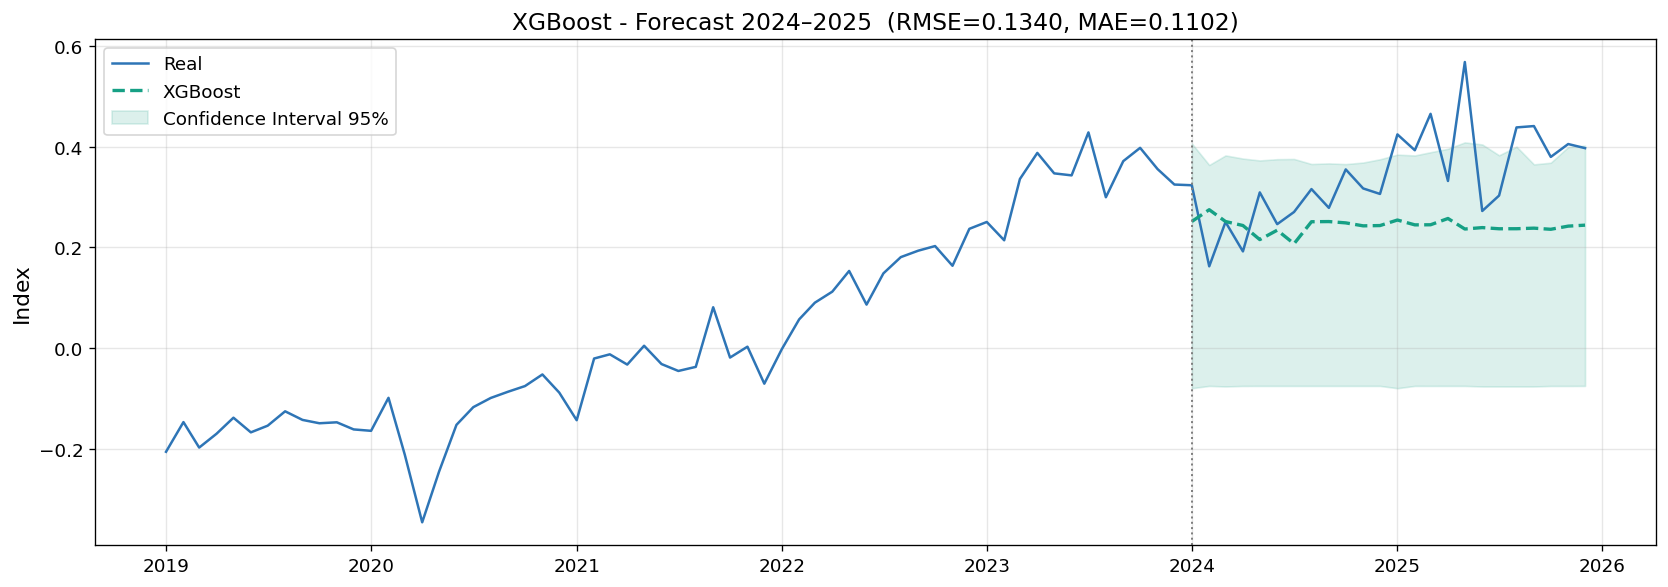

In [41]:
import xgboost as xgb
from sklearn.ensemble import GradientBoostingRegressor

def build_lag_features(series, lookback=12):
    """Generates DataFrame with lags, rolling stats, and calendar features."""
    df = series.to_frame('y')
    for lag in range(1, lookback + 1):
        df[f'lag_{lag}'] = df['y'].shift(lag)
    df['roll_mean_3']  = df['y'].shift(1).rolling(3).mean()   # ~1 quarter
    df['roll_mean_12'] = df['y'].shift(1).rolling(12).mean()  # ~1 year
    df['roll_std_3']   = df['y'].shift(1).rolling(3).std()
    df['roll_std_12']  = df['y'].shift(1).rolling(12).std()
    df['roll_min_12']  = df['y'].shift(1).rolling(12).min()
    df['roll_max_12']  = df['y'].shift(1).rolling(12).max()
    df['mes'] = df.index.month
    df['anio'] = df.index.year
    df['mes_sin'] = np.sin(2 * np.pi * df['mes'] / 12)
    df['mes_cos'] = np.cos(2 * np.pi * df['mes'] / 12)
    # Explicit linear trend: trees don't extrapolate trends on their own
    t0 = df.index[0]
    df['t_norm'] = (df.index - t0).days / 365.25
    return df.dropna()

df_lags = build_lag_features(serie_nac['indice'], lookback=12)
feature_cols = [c for c in df_lags.columns if c != 'y']

# Temporal split (train/test)
df_lags_train = df_lags[df_lags.index <= TRAIN_END].copy()
df_lags_test  = df_lags[df_lags.index >= TEST_START].copy()

# Internal temporal validation for early stopping (no test data used)
val_size = max(8, int(len(df_lags_train) * 0.2))
df_xgb_fit = df_lags_train.iloc[:-val_size].copy()
df_xgb_val = df_lags_train.iloc[-val_size:].copy()

X_xgb_fit, y_xgb_fit = df_xgb_fit[feature_cols], df_xgb_fit['y']
X_xgb_val, y_xgb_val = df_xgb_val[feature_cols], df_xgb_val['y']
X_xgb_te,  y_xgb_te  = df_lags_test[feature_cols], df_lags_test['y']

# ── Main model (point estimate) ───────────────────────────────────────────
xgb_model = xgb.XGBRegressor(
    n_estimators=1200,
    learning_rate=0.03,
    max_depth=3,
    min_child_weight=3,
    subsample=0.85,
    colsample_bytree=0.85,
    reg_alpha=0.05,
    reg_lambda=1.0,
    random_state=SEED,
    early_stopping_rounds=50,
    verbosity=0
)
xgb_model.fit(
    X_xgb_fit, y_xgb_fit,
    eval_set=[(X_xgb_val, y_xgb_val)],
    verbose=False
)

xgb_pred  = xgb_model.predict(X_xgb_te)
xgb_dates = df_lags_test.index

xgb_rmse = np.sqrt(mean_squared_error(y_xgb_te, xgb_pred))
xgb_mae  = mean_absolute_error(y_xgb_te, xgb_pred)
print(f'XGBoost → RMSE = {xgb_rmse:.4f}  |  MAE = {xgb_mae:.4f}')

# ── Prediction intervals: quantile regression via sklearn GBR ─────────────
# sklearn's GradientBoostingRegressor supports loss='quantile' in all versions
X_tr_full = df_lags_train[feature_cols].values
y_tr_full = df_lags_train['y'].values
_best_n   = max(100, (xgb_model.best_iteration or 400) + 1)
_gbr_params = dict(
    n_estimators=_best_n, learning_rate=0.03, max_depth=3,
    min_samples_leaf=3, subsample=0.85, random_state=SEED,
)
_gbr_lo = GradientBoostingRegressor(**_gbr_params, loss='quantile', alpha=0.025)
_gbr_hi = GradientBoostingRegressor(**_gbr_params, loss='quantile', alpha=0.975)
_gbr_lo.fit(X_tr_full, y_tr_full)
_gbr_hi.fit(X_tr_full, y_tr_full)
xgb_ci_lower = _gbr_lo.predict(X_xgb_te.values)
xgb_ci_upper = _gbr_hi.predict(X_xgb_te.values)

resultados['XGBoost'] = {
    'pred'    : xgb_pred,
    'rmse'    : xgb_rmse,
    'mae'     : xgb_mae,
    'dates'   : xgb_dates,
    'ci_lower': xgb_ci_lower,
    'ci_upper': xgb_ci_upper,
}

fig, ax = plt.subplots(figsize=(14, 5))
ax.plot(serie_nac.index, serie_nac['indice'], color='#2E75B6', linewidth=1.5, label='Real')
ax.plot(xgb_dates, xgb_pred, color='#16A085', linewidth=2,
        linestyle='--', label='XGBoost')
ax.fill_between(xgb_dates, xgb_ci_lower, xgb_ci_upper,
                color='#16A085', alpha=0.15, label='Confidence Interval 95%')
ax.axvline(pd.Timestamp(TEST_START), color='gray', linestyle=':', linewidth=1.2)
ax.set_title(f'XGBoost - Forecast 2024–2025  (RMSE={xgb_rmse:.4f}, MAE={xgb_mae:.4f})')
ax.set_ylabel('Index')
ax.legend()
ax.grid(alpha=0.3)
plt.tight_layout()
plt.savefig('plots/xgboost_forecast.png', dpi=150, bbox_inches='tight')
plt.show()

## Step 6.1 — Ensemble: ETS + LSTM + XGBoost

Averaging models with different biases (statistical, neural, tree-based) reduces error variance without adding hyperparameters. A simple arithmetic average is used, which in practice often matches or outperforms more complex weighting schemes.

Ensemble → RMSE = 0.0871  |  MAE = 0.0679


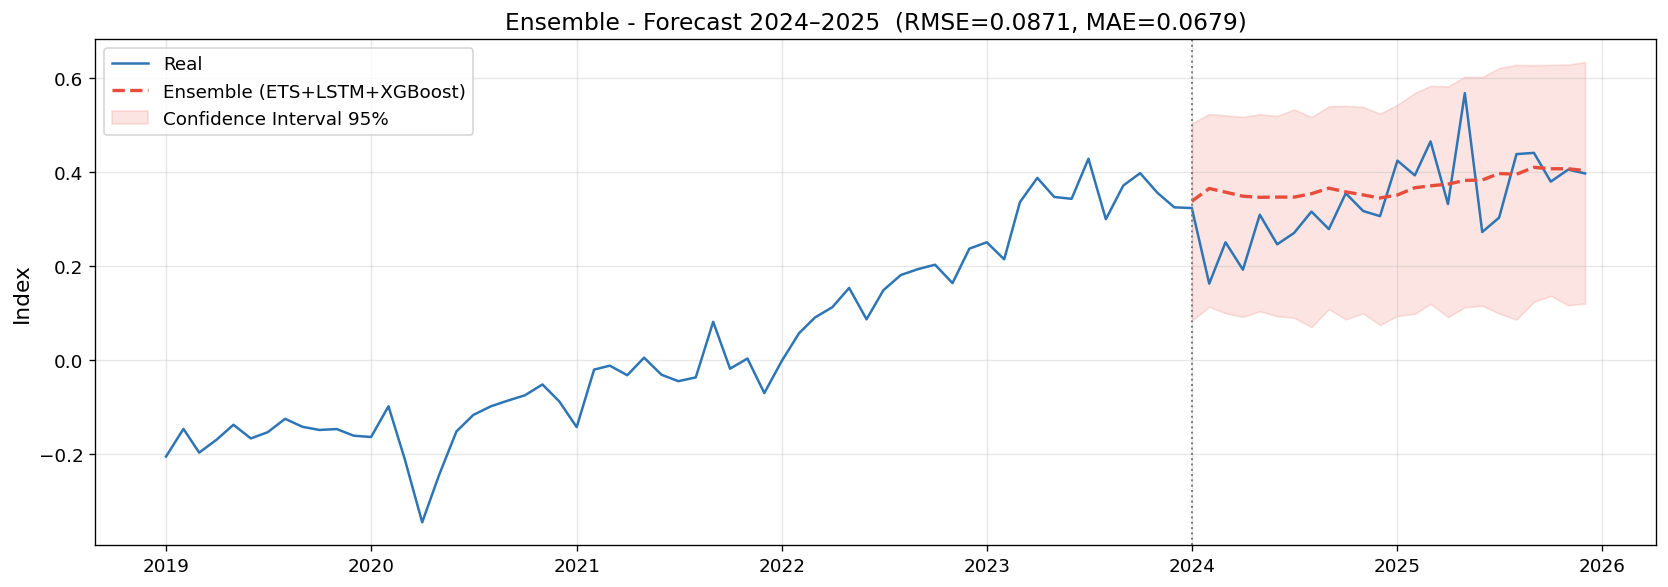

In [42]:
# ── Ensemble: average of ETS + LSTM + XGBoost ────────────────────────────
ens_models = ['ETS', 'LSTM', 'XGBoost']
missing    = [m for m in ens_models if m not in resultados]
if missing:
    print(f'[WARN] Missing models for ensemble: {missing}')
else:
    # Align minimum length across model predictions
    min_len = min(len(resultados[m]['pred']) for m in ens_models)
    ens_preds = np.array([resultados[m]['pred'][:min_len] for m in ens_models])
    ensemble_pred = ens_preds.mean(axis=0)

    # Dates: use the index of the shortest sequence (LSTM)
    if 'dates' in resultados['LSTM']:
        ens_dates = resultados['LSTM']['dates'][:min_len]
    else:
        ens_dates = test_serie.index[:min_len]

    y_true_ens   = test_serie['indice'].reindex(ens_dates).values
    ensemble_rmse = np.sqrt(mean_squared_error(y_true_ens, ensemble_pred))
    ensemble_mae  = mean_absolute_error(y_true_ens, ensemble_pred)
    print(f'Ensemble → RMSE = {ensemble_rmse:.4f}  |  MAE = {ensemble_mae:.4f}')

    # Prediction interval: average of component model CIs
    ens_entry = {
        'pred': ensemble_pred,
        'rmse': ensemble_rmse,
        'mae' : ensemble_mae,
        'dates': ens_dates,
    }
    if all('ci_lower' in resultados[m] for m in ens_models):
        ens_lo = np.array([np.array(resultados[m]['ci_lower'])[:min_len]
                           for m in ens_models]).mean(axis=0)
        ens_hi = np.array([np.array(resultados[m]['ci_upper'])[:min_len]
                           for m in ens_models]).mean(axis=0)
        ens_entry['ci_lower'] = ens_lo
        ens_entry['ci_upper'] = ens_hi
    resultados['Ensemble'] = ens_entry

    fig, ax = plt.subplots(figsize=(14, 5))
    ax.plot(serie_nac.index, serie_nac['indice'], color='#2E75B6',
            linewidth=1.5, label='Real')
    ax.plot(ens_dates, ensemble_pred, color='#E74C3C', linewidth=2,
            linestyle='--', label='Ensemble (ETS+LSTM+XGBoost)')
    if 'ci_lower' in ens_entry:
        ax.fill_between(ens_dates, ens_entry['ci_lower'], ens_entry['ci_upper'],
                        color='#E74C3C', alpha=0.15, label='Confidence Interval 95%')
    ax.axvline(pd.Timestamp(TEST_START), color='gray', linestyle=':', linewidth=1.2)
    ax.set_title(f'Ensemble - Forecast 2024–2025  (RMSE={ensemble_rmse:.4f}, MAE={ensemble_mae:.4f})')
    ax.set_ylabel('Index')
    ax.legend()
    ax.grid(alpha=0.3)
    plt.tight_layout()
    plt.savefig('plots/ensemble_forecast.png', dpi=150, bbox_inches='tight')
    plt.show()

## Step 7 — Final Model Comparison

Comparison of the full model set: ETS, XGBoost, LSTM, ARIMA, and Prophet.
Models are compared using RMSE and MAE on the strictly out-of-sample test period.
Includes a summary table and overlapping forecast visualization for 2024–2025.

### How to Read the Final Table

- **RMSE** penalizes large errors more heavily (useful when forecast spikes matter).
- **MAE** reflects the mean absolute error (easier to interpret in terms of magnitude).

If a complex model does not clearly improve these metrics on the test set, it should not be defended as the final model.

In [43]:
MODELOS_FINALES = ['ETS', 'Ensemble', 'XGBoost', 'LSTM', 'ARIMA', 'Prophet']

rows = [
    {'Modelo': m, 'RMSE': resultados[m]['rmse'], 'MAE': resultados[m]['mae']}
    for m in MODELOS_FINALES if m in resultados
]

tabla = (pd.DataFrame(rows)
           .sort_values('RMSE')
           .reset_index(drop=True))
tabla.index += 1
tabla['RMSE'] = tabla['RMSE'].map('{:.4f}'.format)
tabla['MAE']  = tabla['MAE'].map('{:.4f}'.format)

best = min(MODELOS_FINALES, key=lambda m: resultados[m]['rmse'] if m in resultados else np.inf)
print(f'Mejor modelo: {best} (RMSE={resultados[best]["rmse"]:.4f})\n')
print(tabla.to_string())

# Guardar tabla CSV
tabla.to_csv('data/tabla_modelos_forecasting.csv', index=True)


Mejor modelo: Ensemble (RMSE=0.0871)

     Modelo    RMSE     MAE
1  Ensemble  0.0871  0.0679
2      LSTM  0.1169  0.0963
3   XGBoost  0.1340  0.1102
4       ETS  0.1361  0.1221
5   Prophet  0.1501  0.1362
6     ARIMA  0.1609  0.1486


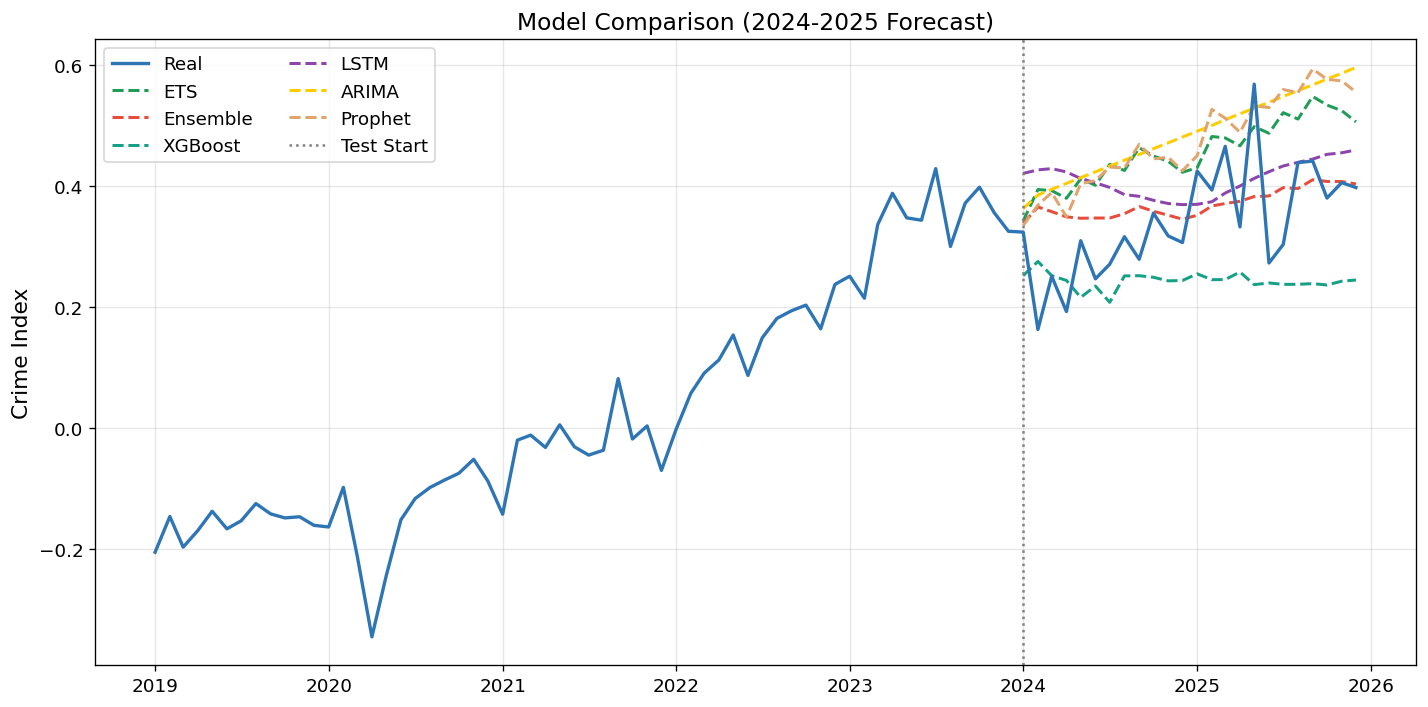

In [44]:
PALETTE_FINAL = {
    'ETS'     : '#1F9D55',
    'Ensemble': '#E74C3C',
    'XGBoost' : '#16A085',
    'LSTM'    : '#8E44AD',
    'ARIMA'   : "#FFCC00",
    'Prophet' : "#E2A46D",
}

fig, ax = plt.subplots(figsize=(12, 6))
ax.plot(serie_nac.index, serie_nac['indice'], color='#2E75B6',
        linewidth=2, label='Real', zorder=10)

for nombre in MODELOS_FINALES:
    if nombre not in resultados:
        continue
    datos  = resultados[nombre]
    color  = PALETTE_FINAL.get(nombre, 'black')
    dates  = datos.get('dates', test_serie.index)
    pred   = np.array(datos['pred'])[:len(dates)]
    ax.plot(dates, pred,
            color=color, linewidth=1.8, linestyle='--',
            label=f"{nombre}")
    # # Confidence bands (95 %)
    # if 'ci_lower' in datos and 'ci_upper' in datos:
    #     ci_lo = np.array(datos['ci_lower'])[:len(dates)]
    #     ci_hi = np.array(datos['ci_upper'])[:len(dates)]
    #     ax.fill_between(dates, ci_lo, ci_hi, color=color, alpha=0.08)

ax.axvline(pd.Timestamp(TEST_START), color='gray', linestyle=':', linewidth=1.5,
           label='Test Start')
ax.set_title('Model Comparison (2024-2025 Forecast)')
ax.set_ylabel('Crime Index')
ax.legend(ncol=2)
ax.grid(alpha=0.3)
plt.tight_layout()
plt.savefig('plots/comparacion_modelos.png', dpi=150, bbox_inches='tight')
plt.show()


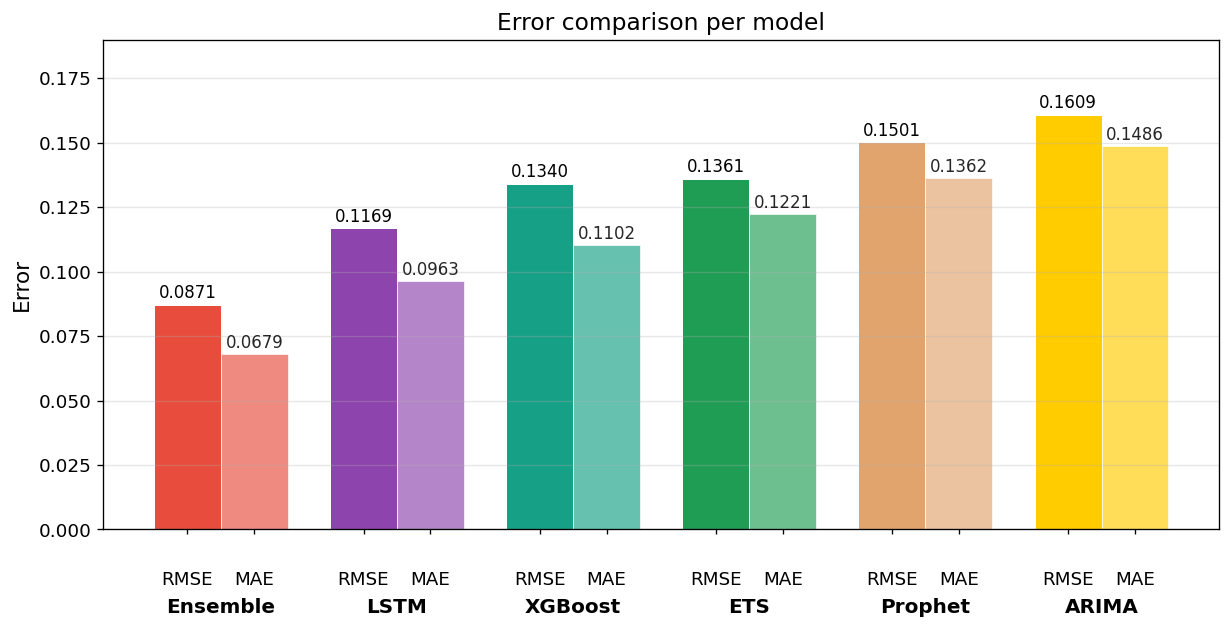

In [45]:

# ── Bar plot: RMSE and MAE per model ──────────────────────────────────────
modelos_bar = [m for m in MODELOS_FINALES if m in resultados]
rmse_vals   = [resultados[m]['rmse'] for m in modelos_bar]
mae_vals    = [resultados[m]['mae']  for m in modelos_bar]

# Sort by ascending RMSE
order = sorted(range(len(modelos_bar)), key=lambda i: rmse_vals[i])
modelos_bar = [modelos_bar[i] for i in order]
rmse_vals   = [rmse_vals[i]   for i in order]
mae_vals    = [mae_vals[i]    for i in order]
colors_bar  = [PALETTE_FINAL.get(m, '#888') for m in modelos_bar]

x      = np.arange(len(modelos_bar))
width  = 0.38

fig, ax = plt.subplots(figsize=(12, 6))
bars1 = ax.bar(x - width / 2, rmse_vals, width,
               color=colors_bar, edgecolor='white', linewidth=0.6)
bars2 = ax.bar(x + width / 2, mae_vals,  width,
               color=colors_bar, edgecolor='white', linewidth=0.6, alpha=0.65)

# Value labels above the bars
for bar in bars1:
    ax.text(bar.get_x() + bar.get_width() / 2, bar.get_height() + 0.001,
            f'{bar.get_height():.4f}', ha='center', va='bottom', fontsize=10)
for bar in bars2:
    ax.text(bar.get_x() + bar.get_width() / 2, bar.get_height() + 0.001,
            f'{bar.get_height():.4f}', ha='center', va='bottom', fontsize=10, alpha=0.85)

# ── Two-level X axis: "RMSE"/"MAE" as sub-ticks, model name as main tick ──
tick_pos = []
tick_lbl = []
for xi in x:
    tick_pos.extend([xi - width / 2, xi + width / 2])
    tick_lbl.extend(['RMSE', 'MAE'])

ax.set_xticks(tick_pos)
ax.set_xticklabels(tick_lbl, fontsize=11)
ax.tick_params(axis='x', which='major', length=3, pad=22)

# Model names as second row below RMSE/MAE
for xi, m in zip(x, modelos_bar):
    ax.text(xi, -0.14, m,
            transform=ax.get_xaxis_transform(),
            ha='center', va='top', fontsize=12, fontweight='bold')

ax.set_ylabel('Error', fontsize=13)
ax.set_title('Error comparison per model', fontsize=14)
ax.grid(axis='y', alpha=0.3)
ax.set_ylim(0, max(rmse_vals + mae_vals) * 1.18)
plt.subplots_adjust(bottom=0.20)
plt.savefig('plots/comparacion_errores_bar.png', dpi=150, bbox_inches='tight')
plt.show()